**Logistic Regression Tutorial**: From Non-linear Data to Optimization

This script provides a comprehensive, hands-on guide to understanding and
implementing logistic regression for a non-linear classification problem.
It covers feature engineering, regularization, hyperparameter tuning, and
a comparison of different gradient descent optimization algorithms.

We will use NumPy for numerical operations and Matplotlib for visualization.
Scikit-learn is used only for generating a sample dataset.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
import os

# --- Part 0: Data Generation and Visualization ---
# We'll use scikit-learn's make_circles function to generate a dataset
# where the data is not linearly separable. This is a classic example
# that requires a non-linear decision boundary.

X, y = make_circles(n_samples=500, noise=0.1, factor=0.5, random_state=42)

# Reshape y to be a column vector (n_samples, 1)
y = y.reshape(-1, 1)

# Split data into training, validation, and test sets
# 70% training, 15% validation, 15% testing
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=(0.15/0.85), random_state=42
)


--- Visualizing Initial Data ---


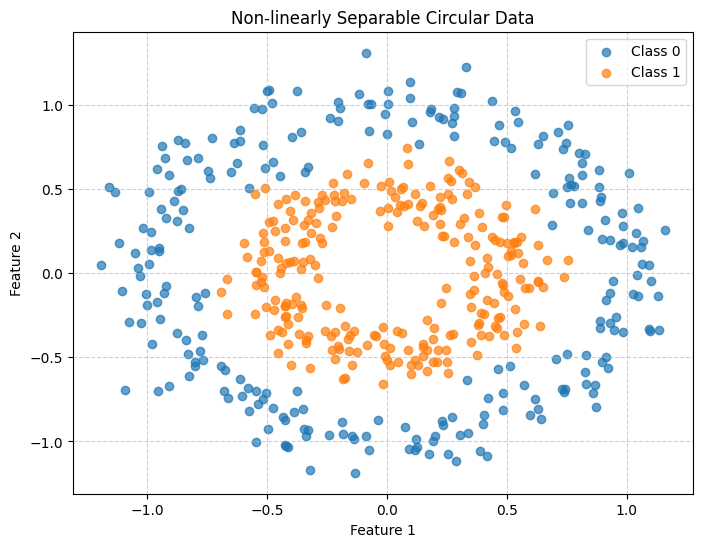

In [2]:
def plot_data(X, y, title="Dataset"):
    """Helper function to visualize the dataset."""
    plt.figure(figsize=(8, 6))
    plt.scatter(X[y.flatten() == 0, 0], X[y.flatten() == 0, 1], label="Class 0", alpha=0.7)
    plt.scatter(X[y.flatten() == 1, 0], X[y.flatten() == 1, 1], label="Class 1", alpha=0.7)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.title(title)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    if not os.environ.get('HIDE_PLOTS', False): plt.show()

print("--- Visualizing Initial Data ---")
plot_data(X, y, "Non-linearly Separable Circular Data")

# --- Part 1: Logistic Regression with Non-linear Features ---

In [3]:
def plot_decision_boundary(model, X, y, title="Decision Boundary", save_fname=None):
    """Helper function to plot the decision boundary of a trained model."""
    plt.figure(figsize=(8, 6))

    # Plot data points
    plt.scatter(X[y.flatten() == 0, 0], X[y.flatten() == 0, 1], label="Class 0", alpha=0.7)
    plt.scatter(X[y.flatten() == 1, 0], X[y.flatten() == 1, 1], label="Class 1", alpha=0.7)

    # Create a grid to evaluate the model
    x1_min, x1_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    x2_min, x2_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx1, xx2 = np.meshgrid(np.linspace(x1_min, x1_max, 200),
                           np.linspace(x2_min, x2_max, 200))

    # Predict on the grid
    grid_X = np.c_[xx1.ravel(), xx2.ravel()]

    # Apply the same feature transformation used for training
    if hasattr(model, 'poly_features') and model.poly_features:
        grid_X_poly = model.transform(grid_X)
    else:
        grid_X_poly = grid_X

    Z = model.predict(grid_X_poly)
    Z = Z.reshape(xx1.shape)

    # Plot the contour
    plt.contourf(xx1, xx2, Z, alpha=0.3, levels=[0, 0.5, 1], colors=['#3B82F6', '#F472B6'])

    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.title(title)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    if save_fname:
      if not os.environ.get('HIDE_PLOTS', False): plt.savefig(save_fname) # Save the plot

    if not os.environ.get('HIDE_PLOTS', False): plt.show()

In [4]:
class LogisticRegression:
    def __init__(self, learning_rate=0.01, n_iterations=10000, lambda_val=0.1, regularization=None, poly_features=False):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.lambda_val = lambda_val  # Regularization strength
        self.regularization = regularization  # 'L1' or 'L2'
        self.poly_features = poly_features # Flag for polynomial feature transformation
        self.weights = None
        self.bias = None

    def _sigmoid(self, z):
        #TODO: (1a) Implement sigmoid function
        # Hint: The sigmoid function is defined as 1 / (1 + e^(-z)).
        return 1/(np.exp(-1 * z) + 1)
        

    def transform(self, X):
        """b. Create new features by non-linear transforms (e.g. squares)"""
        # Original features: X1, X2
        # New features: X1, X2, X1^2, X2^2, X1*X2
        # Should return a np.hstack() containing X1, X2, X1^2, X2^2, X1*X2

        #TODO: (1b) implement feature transform
        # Hint: X1 is the first column of X (X[:, 0]) and X2 is the second (X[:, 1]).
        # Create the new feature columns and then stack them horizontally with the original X.
        # The final returned array should have 5 columns.
        X1 = X[:,0].reshape(-1,1)
        X2 = X[:,1].reshape(-1,1)

        X1_2 = np.square(X1)
        X2_2 = np.square(X2)

        X12 = np.multiply(X1, X2)
        # print(X.shape, X1.shape, X2.shape, np.hstack((X1, X2)).shape)
        return np.hstack((X1, X2, X1_2, X2_2, X12))

    def _compute_cost(self, y, y_pred):
        m = len(y)
        # TODO: (1c) implement cost function
        # Hint: Implement the binary cross-entropy (log loss) cost function.
        # Formula: J = -(1/m) * Σ [y*log(y_pred) + (1-y)*log(1-y_pred)]
        # Be careful about taking the log of 0.
        cost = (-1/m) * np.sum(np.multiply(y, np.log(y_pred)) + np.multiply((1 - y), np.log((1 - y_pred))))

        # Add regularization term
        reg_cost = 0
        if self.regularization == 'L2':
            #TODO: (2a) implement L2 Regularization
            # from https://medium.com/data-science/understanding-the-scaling-of-l%C2%B2-regularization-in-the-context-of-neural-networks-e3d25f8b50db
            reg_cost = (self.lambda_val / (2*m)) * np.sum(np.square(self.weights))
        elif self.regularization == 'L1':
            #TODO: (2b) implement L1 Regularization
            reg_cost = (self.lambda_val / m) * np.sum(np.abs(self.weights))
        # print("regularization:", reg_cost)

        return cost + reg_cost

    def fit(self, X, y):
        # Apply polynomial transformation if specified
        if self.poly_features:
            X = self.transform(X)

        n_samples, n_features = X.shape
        self.weights = np.zeros((n_features, 1))
        self.bias = 0
        self.costs = []

        # Batch Gradient Descent
        for i in range(self.n_iterations):
            linear_model = np.dot(X, self.weights) + self.bias
            y_pred = self._sigmoid(linear_model)

            # Compute cost for visualization
            cost = self._compute_cost(y, y_pred)
            self.costs.append(cost)

            # Compute gradients
            #TODO: (1d) compute gradients
            dw = np.matmul(np.transpose(X), (y_pred - y))/len(y)
            db = np.mean(y_pred - y)

            # Add regularization to gradients
            if self.regularization == 'L2':
                dw += (self.lambda_val / n_samples) * self.weights
            elif self.regularization == 'L1':
                # Subgradient of L1
                dw += (self.lambda_val / n_samples) * np.sign(self.weights)

            # Update weights and bias
            # TODO: (1a) update weights and bias
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

            if i % 1000 == 0:
                print(f"Cost after iteration {i}: {cost:.4f}")

    def predict(self, X):
        # Note: The model expects the same feature transformation as during training.
        # The plotting function handles this transformation.
        linear_model = np.dot(X, self.weights) + self.bias
        y_pred = self._sigmoid(linear_model)
        return (y_pred > 0.5).astype(int)

Cost after iteration 0: 0.6931
Cost after iteration 1000: 0.6912
Cost after iteration 2000: 0.6912
Cost after iteration 3000: 0.6912
Cost after iteration 4000: 0.6912
Cost after iteration 5000: 0.6912
Cost after iteration 6000: 0.6912
Cost after iteration 7000: 0.6912
Cost after iteration 8000: 0.6912
Cost after iteration 9000: 0.6912
Cost after iteration 10000: 0.6912
Cost after iteration 11000: 0.6912
Cost after iteration 12000: 0.6912
Cost after iteration 13000: 0.6912
Cost after iteration 14000: 0.6912
Cost after iteration 15000: 0.6912
Cost after iteration 16000: 0.6912
Cost after iteration 17000: 0.6912
Cost after iteration 18000: 0.6912
Cost after iteration 19000: 0.6912


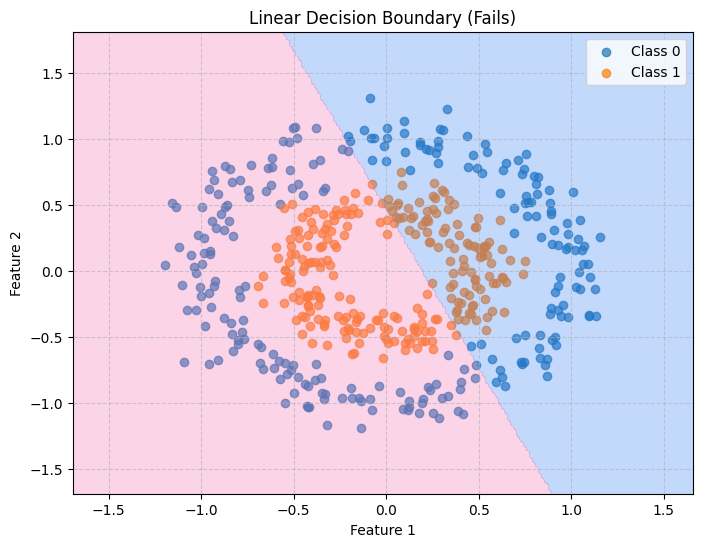

In [5]:
# 1.a. Attempt to fit with a simple linear model
linear_model = LogisticRegression(learning_rate=0.1, n_iterations=20000)
linear_model.fit(X_train, y_train)
plot_decision_boundary(linear_model, X, y, "Linear Decision Boundary (Fails)", "submission_4a_linear_decision_boundary.png")

Cost after iteration 0: 0.6931
Cost after iteration 1000: 0.2330
Cost after iteration 2000: 0.1560
Cost after iteration 3000: 0.1240
Cost after iteration 4000: 0.1061
Cost after iteration 5000: 0.0945
Cost after iteration 6000: 0.0863
Cost after iteration 7000: 0.0801
Cost after iteration 8000: 0.0752
Cost after iteration 9000: 0.0713
Cost after iteration 10000: 0.0680
Cost after iteration 11000: 0.0653
Cost after iteration 12000: 0.0629
Cost after iteration 13000: 0.0608
Cost after iteration 14000: 0.0590
Cost after iteration 15000: 0.0574
Cost after iteration 16000: 0.0559
Cost after iteration 17000: 0.0546
Cost after iteration 18000: 0.0534
Cost after iteration 19000: 0.0523


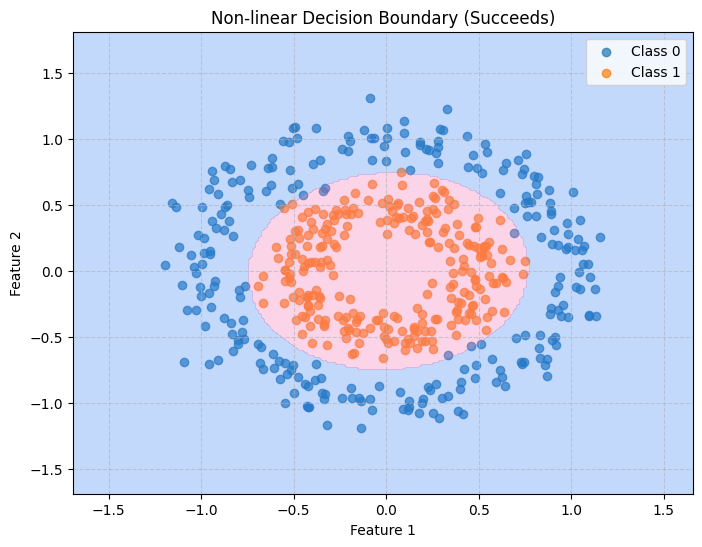

In [6]:
nonlinear_model = LogisticRegression(learning_rate=0.1, n_iterations=20000, poly_features=True)
nonlinear_model.fit(X_train, y_train)
plot_decision_boundary(nonlinear_model, X, y, "Non-linear Decision Boundary (Succeeds)", "submission_4a_nonlinear_decision_boundary.png")

# --- Part 2: L1 vs. L2 Regularization ---

Regularization helps prevent overfitting by penalizing large weights.

Overfitting occurs when a model learns the training data too well, including the noise and outliers, leading to poor performance on unseen data. Large weights in a logistic regression model can cause the decision boundary to be too complex and highly sensitive to small changes in the input features, which is a sign of overfitting.

Regularization adds a penalty term to the cost function that is minimized during training. This penalty is based on the magnitude of the weights. By adding this penalty, the model is encouraged to keep the weights small.

*   **L1 Regularization (Lasso):** Adds the sum of the absolute values of the weights to the cost function. This encourages sparsity, meaning it can drive some weights exactly to zero, effectively performing feature selection.
*   **L2 Regularization (Ridge):** Adds the sum of the squared values of the weights to the cost function. This shrinks the weights towards zero but rarely makes them exactly zero. L2 regularization is good at preventing multicollinearity (high correlation between features).

By limiting the size of the weights, regularization makes the model simpler and less prone to fitting the noise in the training data, thus improving its generalization ability on new data.

Implement the L1 and L2 regularization above to complete the following section.

Training L2 (Ridge) Regularized Model...
Cost after iteration 0: 0.6931
Cost after iteration 1000: 0.2674
Cost after iteration 2000: 0.2174
Cost after iteration 3000: 0.2038
Cost after iteration 4000: 0.1990
Cost after iteration 5000: 0.1971
Cost after iteration 6000: 0.1963
Cost after iteration 7000: 0.1960
Cost after iteration 8000: 0.1958
Cost after iteration 9000: 0.1957
Cost after iteration 10000: 0.1957
Cost after iteration 11000: 0.1957
Cost after iteration 12000: 0.1957
Cost after iteration 13000: 0.1957
Cost after iteration 14000: 0.1957
Cost after iteration 15000: 0.1957
Cost after iteration 16000: 0.1957
Cost after iteration 17000: 0.1957
Cost after iteration 18000: 0.1957
Cost after iteration 19000: 0.1957


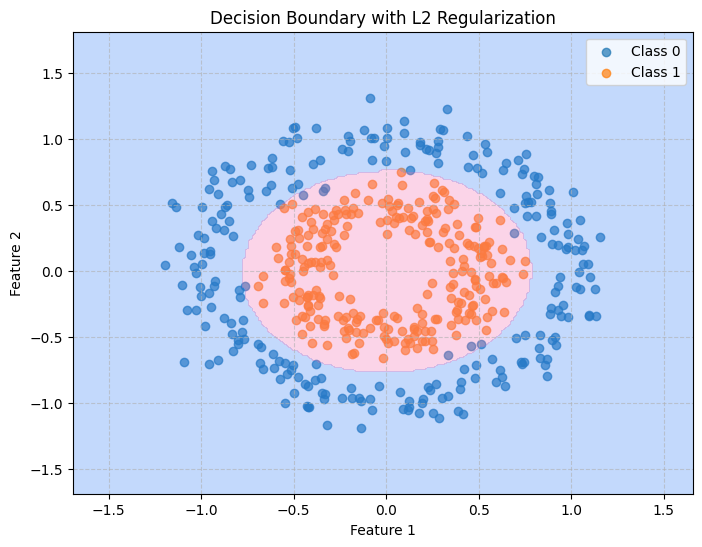

In [7]:
print("Training L2 (Ridge) Regularized Model...")
l2_model = LogisticRegression(learning_rate=0.1, n_iterations=20000,
                              regularization='L2', lambda_val=0.5, poly_features=True)
l2_model.fit(X_train, y_train)
plot_decision_boundary(l2_model, X, y, "Decision Boundary with L2 Regularization")


Training L1 (Lasso) Regularized Model...
Cost after iteration 0: 0.6931
Cost after iteration 1000: 0.2492
Cost after iteration 2000: 0.1774
Cost after iteration 3000: 0.1489
Cost after iteration 4000: 0.1337
Cost after iteration 5000: 0.1242
Cost after iteration 6000: 0.1177
Cost after iteration 7000: 0.1131
Cost after iteration 8000: 0.1096
Cost after iteration 9000: 0.1068
Cost after iteration 10000: 0.1046
Cost after iteration 11000: 0.1029
Cost after iteration 12000: 0.1014
Cost after iteration 13000: 0.1002
Cost after iteration 14000: 0.0991
Cost after iteration 15000: 0.0982
Cost after iteration 16000: 0.0974
Cost after iteration 17000: 0.0968
Cost after iteration 18000: 0.0962
Cost after iteration 19000: 0.0957


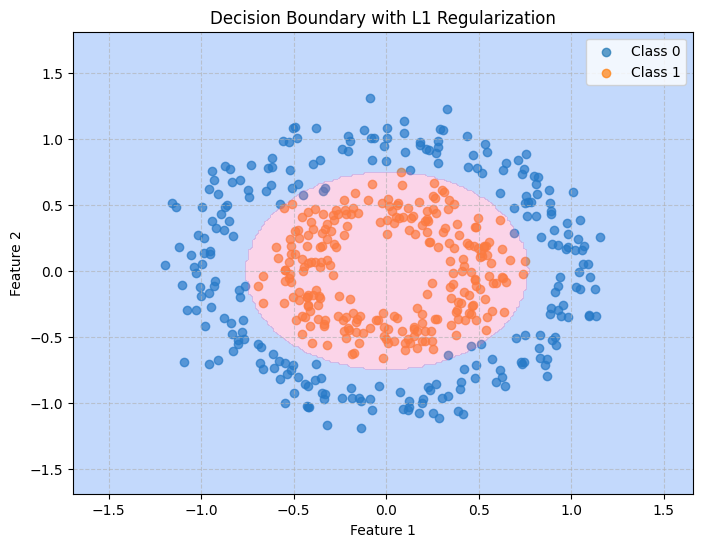

In [8]:
print("\nTraining L1 (Lasso) Regularized Model...")
l1_model = LogisticRegression(learning_rate=0.1, n_iterations=20000,
                              regularization='L1', lambda_val=0.5, poly_features=True)
l1_model.fit(X_train, y_train)
plot_decision_boundary(l1_model, X, y, "Decision Boundary with L1 Regularization")


--- Comparing Model Weights ---
L2 Model Weights:
[ 0.07454624 -0.10389005 -7.2384758  -7.54392777  0.24330994]
L1 Model Weights:
[ 1.47228113e-01 -2.00584631e-04 -1.21424675e+01 -1.25736263e+01
  1.55651432e-01]


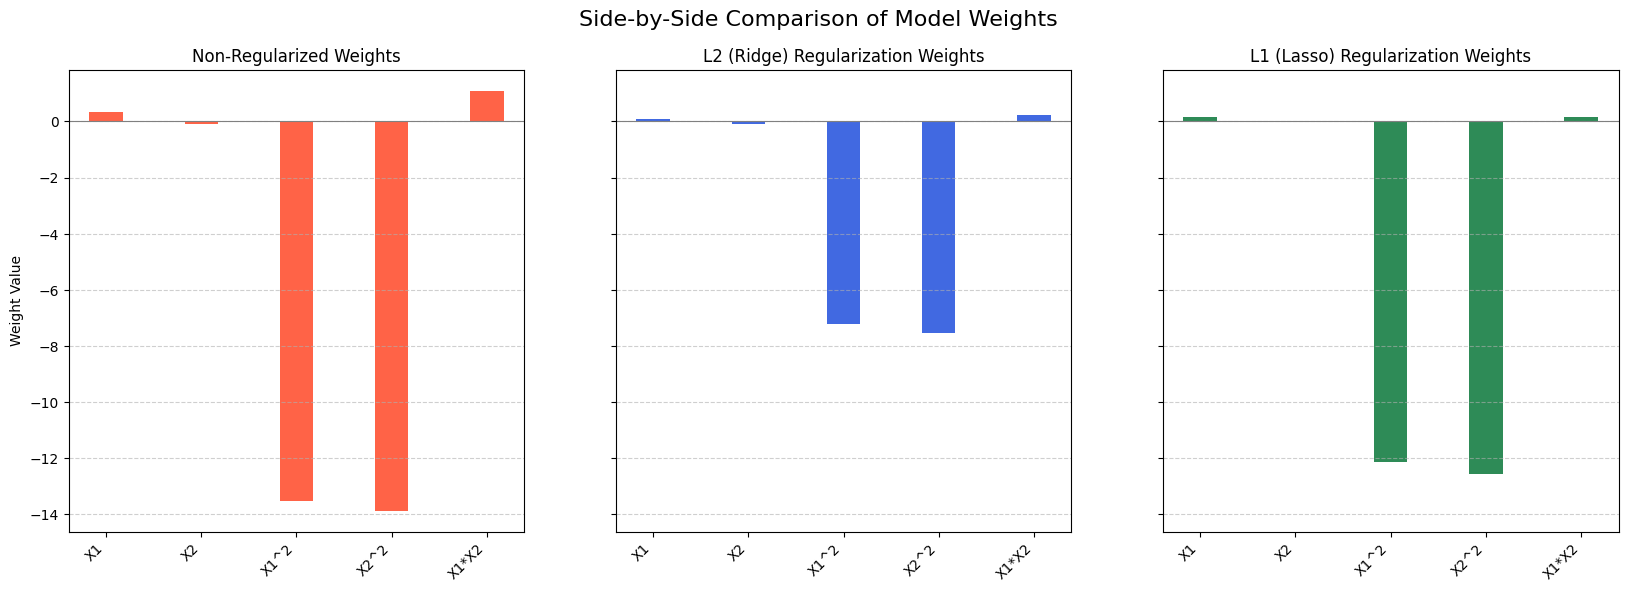

In [9]:
print("\n--- Comparing Model Weights ---")
print(f"L2 Model Weights:\n{l2_model.weights.flatten()}")
print(f"L1 Model Weights:\n{l1_model.weights.flatten()}")

# --- New Visualization for Comparing L1 and L2 Weights ---
feature_names = ['X1', 'X2', 'X1^2', 'X2^2', 'X1*X2']
non_reg_weights = nonlinear_model.weights.flatten()
l2_weights = l2_model.weights.flatten()
l1_weights = l1_model.weights.flatten()

x = np.arange(len(feature_names))  # the label locations
width = 0.35  # the width of the bars

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6), sharey=True)

# Plot Non-regularized weights
rects1 = ax1.bar(x, non_reg_weights, width, label='Non-Regularized', color='tomato')
ax1.set_ylabel('Weight Value')
ax1.set_title('Non-Regularized Weights')
ax1.set_xticks(x)
ax1.set_xticklabels(feature_names, rotation=45, ha="right")
ax1.axhline(0, color='grey', linewidth=0.8)
ax1.grid(True, axis='y', linestyle='--', alpha=0.6)

# Plot L2 weights
rects2 = ax2.bar(x, l2_weights, width, label='L2 Weights', color='royalblue')
ax2.set_title('L2 (Ridge) Regularization Weights')
ax2.set_xticks(x)
ax2.set_xticklabels(feature_names, rotation=45, ha="right")
ax2.axhline(0, color='grey', linewidth=0.8)
ax2.grid(True, axis='y', linestyle='--', alpha=0.6)

# Plot L1 weights
rects3 = ax3.bar(x, l1_weights, width, label='L1 Weights', color='seagreen')
ax3.set_title('L1 (Lasso) Regularization Weights')
ax3.set_xticks(x)
ax3.set_xticklabels(feature_names, rotation=45, ha="right")
ax3.axhline(0, color='grey', linewidth=0.8)
ax3.grid(True, axis='y', linestyle='--', alpha=0.6)

fig.suptitle('Side-by-Side Comparison of Model Weights', fontsize=16)
if not os.environ.get('HIDE_PLOTS', False): plt.savefig("submission_4b.png") # Save the plot

if not os.environ.get('HIDE_PLOTS', False): plt.show()

# --- Part 3: Hyperparameter Tuning (Grid Search) ---

We will search for the best learning_rate (alpha) and regularization strength (lambda) using the validation set.

In [10]:
#TODO: (3) define a list of at least 3 learning rates and at least 3 lambda values you want to validate
learning_rates = [0.9, 0.5, 0.25, 0.1, 0.01]
lambda_values = [0.9, 0.5, 0.25, 0.1, 0.01]
best_accuracy = 0
best_params = {}
best_model = None

# Array to store the results for visualization
grid_search_results = np.zeros((len(learning_rates), len(lambda_values)))


# Transform validation set once
X_val_poly = nonlinear_model.transform(X_val)

for i, lr in enumerate(learning_rates):
    for j, lmbda in enumerate(lambda_values):
        print(f"Training with lr={lr}, lambda={lmbda}...")
        model = LogisticRegression(learning_rate=lr, n_iterations=5000,
                                   regularization='L2', lambda_val=lmbda, poly_features=True)
        model.fit(X_train, y_train)

        # Evaluate on the validation set
        predictions = model.predict(X_val_poly)
        accuracy = np.mean(predictions == y_val)
        grid_search_results[i, j] = accuracy
        print(f"Validation Accuracy: {accuracy * 100:.2f}%")

        if accuracy > best_accuracy:
            best_accuracy = accuracy
            best_params = {'learning_rate': lr, 'lambda_val': lmbda}
            best_model = model

print("\n--- Grid Search Results ---")
print(f"Best parameters found: {best_params}")
print(f"Best validation accuracy: {best_accuracy * 100:.2f}%")

Training with lr=0.9, lambda=0.9...
Cost after iteration 0: 0.6931
Cost after iteration 1000: 0.2463
Cost after iteration 2000: 0.2463
Cost after iteration 3000: 0.2463
Cost after iteration 4000: 0.2463
Validation Accuracy: 100.00%
Training with lr=0.9, lambda=0.5...
Cost after iteration 0: 0.6931
Cost after iteration 1000: 0.1957
Cost after iteration 2000: 0.1957
Cost after iteration 3000: 0.1957
Cost after iteration 4000: 0.1957
Validation Accuracy: 100.00%
Training with lr=0.9, lambda=0.25...
Cost after iteration 0: 0.6931
Cost after iteration 1000: 0.1488
Cost after iteration 2000: 0.1479
Cost after iteration 3000: 0.1479
Cost after iteration 4000: 0.1479
Validation Accuracy: 100.00%
Training with lr=0.9, lambda=0.1...
Cost after iteration 0: 0.6931
Cost after iteration 1000: 0.1081
Cost after iteration 2000: 0.1029
Cost after iteration 3000: 0.1023
Cost after iteration 4000: 0.1022
Validation Accuracy: 100.00%
Training with lr=0.9, lambda=0.01...
Cost after iteration 0: 0.6931
Cos


Evaluating best model on the test set...
Test Set Accuracy: 98.67%


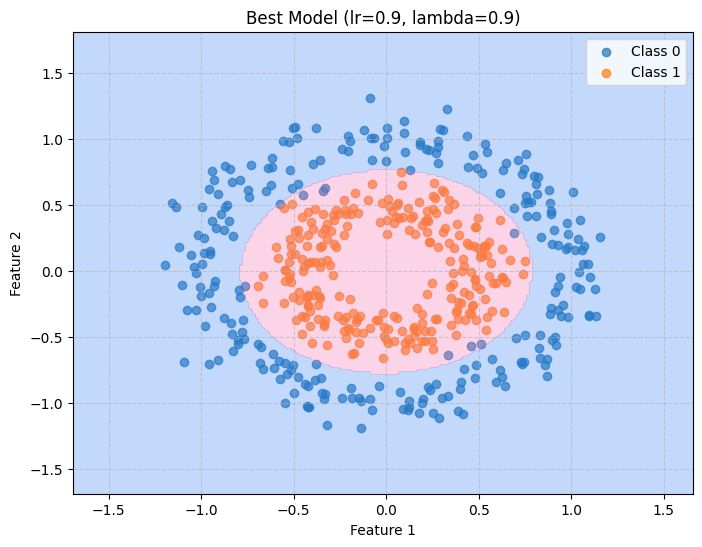

In [11]:
# Evaluate the best model on the unseen test set
print("\nEvaluating best model on the test set...")
X_test_poly = best_model.transform(X_test)
test_predictions = best_model.predict(X_test_poly)
test_accuracy = np.mean(test_predictions == y_test)
print(f"Test Set Accuracy: {test_accuracy * 100:.2f}%")
plot_decision_boundary(best_model, X, y, f"Best Model (lr={best_params['learning_rate']}, lambda={best_params['lambda_val']})", 'submission_4c.png')

# --- Part 4: Gradient Descent Variants ---

In [12]:
X_train_poly = nonlinear_model.transform(X_train) # Pre-transform for this part

def run_gd_variant(optimizer='batch', batch_size=32, n_epochs=100):
    n_samples, n_features = X_train_poly.shape
    weights = np.zeros((n_features, 1))
    bias = 0
    costs = []

    if optimizer == 'batch':
        iterations_per_epoch = 1
    elif optimizer == 'stochastic':
        iterations_per_epoch = n_samples
    elif optimizer == 'mini-batch':
        iterations_per_epoch = int(np.ceil(n_samples / batch_size))

    for epoch in range(n_epochs):
        epoch_cost = 0

        # Shuffle data at the start of each epoch
        permutation = np.random.permutation(n_samples)
        X_shuffled = X_train_poly[permutation]
        y_shuffled = y_train[permutation]
        # print(X_shuffled.shape, y_shuffled.shape)

        for i in range(0, n_samples, batch_size if optimizer != 'stochastic' else 1):
            # TODO: (4) fix X_batch and y_batch below for each of these three cases
            if optimizer == 'stochastic':
                 # Hint: For SGD, the batch size is 1. Slice a single sample (row
                 X_batch = X_shuffled[:1,]
                 y_batch = y_shuffled[:1,]
            elif optimizer == 'mini-batch':
                 # Hint: For Mini-batch GD, slice a chunk of `batch_size` samples
                 X_batch = X_shuffled[:16,]
                 y_batch = y_shuffled[:16,]
            else: # batch
                 # Hint: For Batch GD, the "batch" is the entire training set.
                 X_batch = X_shuffled
                 y_batch = y_shuffled
            # print(X_batch.shape, y_batch.shape)

            m_batch = len(y_batch)
            if m_batch == 0: continue

            linear_model = np.dot(X_batch, weights) + bias
            y_pred = 1 / (1 + np.exp(-linear_model))

            cost = -1/m_batch * np.sum(y_batch * np.log(y_pred) + (1 - y_batch) * np.log(1 - y_pred))
            epoch_cost += cost

            dw = (1 / m_batch) * np.dot(X_batch.T, (y_pred - y_batch))
            db = (1 / m_batch) * np.sum(y_pred - y_batch)

            weights -= 0.1 * dw
            bias -= 0.1 * db

        costs.append(epoch_cost / iterations_per_epoch)

    return costs

In [13]:
# Run the optimizers
cost_batch = run_gd_variant(optimizer='batch', n_epochs=500)
cost_stochastic = run_gd_variant(optimizer='stochastic', n_epochs=500)
cost_mini_batch = run_gd_variant(optimizer='mini-batch', batch_size=32, n_epochs=500)

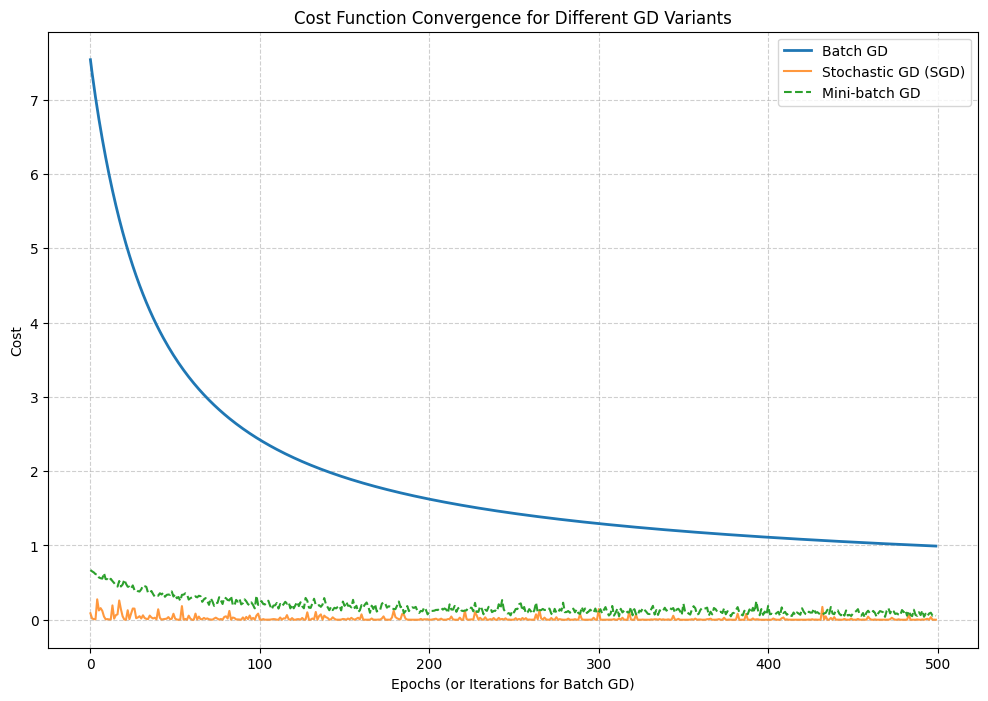

In [14]:
# Visualize the cost functions
plt.figure(figsize=(12, 8))
plt.plot(cost_batch, label='Batch GD', linewidth=2)
plt.plot(cost_stochastic, label='Stochastic GD (SGD)', alpha=0.8)
plt.plot(cost_mini_batch, label='Mini-batch GD', linestyle='--')
plt.xlabel("Epochs (or Iterations for Batch GD)")
plt.ylabel("Cost")
plt.title("Cost Function Convergence for Different GD Variants")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
if not os.environ.get('HIDE_PLOTS', False): plt.savefig("submission_4d.png") # Save the plot
if not os.environ.get('HIDE_PLOTS', False): plt.show()